Loading data from Electric_Production.csv...
--- ARIMA Model Training Complete ---
Order: (5, 1, 0)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0650      0.044     -1.488      0.137      -0.151       0.021
ar.L2         -0.4828      0.049     -9.859      0.000      -0.579      -0.387
ar.L3         -0.5190      0.047    -11.102      0.000      -0.611      -0.427
ar.L4         -0.4530      0.045     -9.999      0.000      -0.542      -0.364
ar.L5         -0.0775      0.057     -1.365      0.172      -0.189       0.034
sigma2        15.0763      0.986     15.290      0.000      13.144      17.009

ARIMA Forecast for next 10 periods:
[121.19024647 104.31328875  93.59175764  98.70127818 114.88779824
 125.21504035 120.24176867 105.69457589  95.95306478 100.25817927]


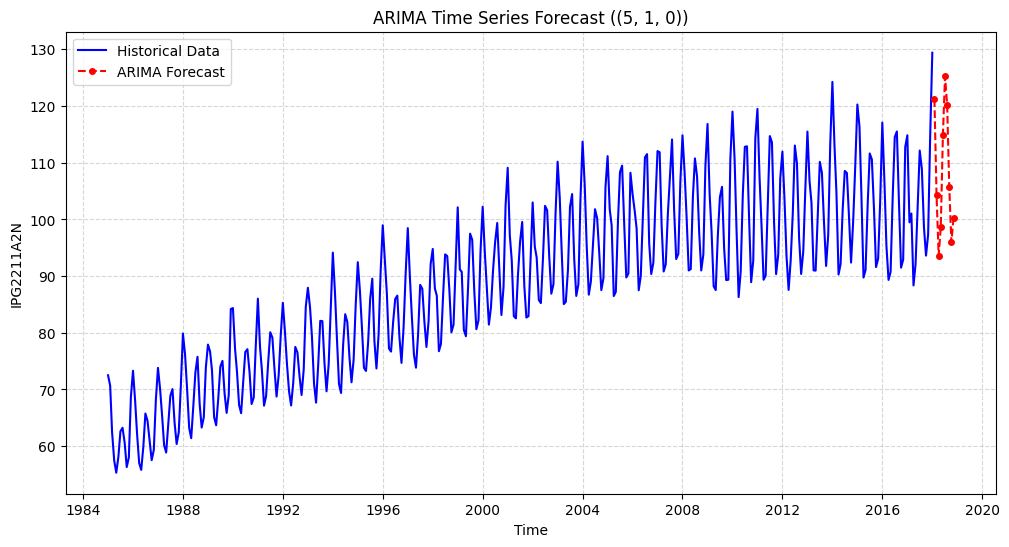

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

class ARIMAModel:
    """
    A class to perform Time Series Analysis using the ARIMA model.
    ARIMA consists of:
    - AR (Autoregression): Relationship between an observation and lagged observations.
    - I (Integrated): Differencing of raw observations to make the time series stationary.
    - MA (Moving Average): Relationship between an observation and residual errors from a moving average model.
    """
    
    def __init__(self, order=(1, 1, 1)):
        """
        order: tuple (p, d, q)
        p: Lag order (AR)
        d: Degree of differencing (I)
        q: Order of moving average (MA)
        """
        self.order = order
        self.model_fit = None
        self.history = None

    def fit(self, data):
        """
        Fits the ARIMA model to the provided data.
        """
        self.history = list(data)
        # Initialize and fit the model
        model = ARIMA(self.history, order=self.order)
        self.model_fit = model.fit()
        
        print(f"--- ARIMA Model Training Complete ---")
        print(f"Order: {self.order}")
        print(self.model_fit.summary().tables[1]) # Print coefficient table

    def forecast(self, steps=5):
        """
        Forecasts future values.
        """
        if self.model_fit is None:
            raise ValueError("Model must be fitted before forecasting.")
            
        # Generate forecast
        forecast_output = self.model_fit.forecast(steps=steps)
        return forecast_output

def load_timeseries_csv(file_path, date_col, value_col):
    """
    Loads a CSV, parses dates, and prepares the series for analysis.
    """
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path)
    
    # 1. Convert date column to datetime objects
    df[date_col] = pd.to_datetime(df[date_col])
    
    # 2. Sort by date
    df = df.sort_values(by=date_col)
    
    # 3. Handle missing values
    df[value_col] = df[value_col].interpolate(method='linear')
    
    return df[date_col].values, df[value_col].values

# --- CONFIGURATION SECTION ---
CONFIG = {
    "file_path": "Electric_Production.csv", # CHANGE 1: Path to your CSV
    "date_column": "DATE",                # CHANGE 2: Timestamp column
    "value_column": "IPG2211A2N",              # CHANGE 3: Value column
    "forecast_steps": 10,                 # CHANGE 4: Steps to forecast
    "arima_order": (5, 1, 0)              # CHANGE 5: (p, d, q) parameters
}

if __name__ == "__main__":
    try:
        # 1. Load and Prepare
        dates, values = load_timeseries_csv(
            CONFIG["file_path"], 
            CONFIG["date_column"], 
            CONFIG["value_column"]
        )

        # 2. Initialize and Train
        # Higher 'p' values look further back in time
        # 'd' of 1 is common to remove trends
        model = ARIMAModel(order=CONFIG["arima_order"])
        model.fit(values)

        # 3. Forecast
        future_predictions = model.forecast(steps=CONFIG["forecast_steps"])
        
        # Generate future dates for plotting
        # Calculating frequency automatically
        date_diff = dates[-1] - dates[-2]
        future_dates = [dates[-1] + (i + 1) * date_diff for i in range(CONFIG["forecast_steps"])]

        print(f"\nARIMA Forecast for next {CONFIG['forecast_steps']} periods:")
        print(future_predictions)

        # 4. Visualization
        plt.figure(figsize=(12, 6))
        plt.plot(dates, values, label='Historical Data', color='blue', linewidth=1.5)
        plt.plot(future_dates, future_predictions, 'o--', label='ARIMA Forecast', color='red', markersize=4)
        
        plt.title(f'ARIMA Time Series Forecast ({CONFIG["arima_order"]})')
        plt.xlabel('Time')
        plt.ylabel(CONFIG["value_column"])
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    except FileNotFoundError:
        print(f"Error: Could not find file '{CONFIG['file_path']}'.")
    except Exception as e:
        print(f"An error occurred: {e}")
        print("Note: Ensure 'statsmodels' is installed: pip install statsmodels")